In [ ]:
!pip install tensorflow
!pip install opencv-python
!pip install imutils

In [ ]:
import tensorflow
from PIL import Image
import glob
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, save_img, img_to_array
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization,Conv2D, SeparableConv2D, MaxPool2D, LeakyReLU, Activation,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau,EarlyStopping
from tensorflow.keras.applications.imagenet_utils import preprocess_input
from sklearn.metrics import classification_report,accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import numpy as np
from tqdm import tqdm
from sklearn.utils import shuffle
import cv2
import os
import shutil
import itertools
import imutils
from sklearn.model_selection import StratifiedKFold
import random
from tensorflow.keras import layers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

x_train = [] # training images.
y_train  = [] # training labels.
x_test = [] # testing images.
y_test = [] # testing labels.

image_size = 200


for label in labels:
    trainPath = os.path.join('/content/drive/MyDrive/dataset_RE/cropped/Training',label)
    for file in tqdm(os.listdir(trainPath)):
        image = cv2.imread(os.path.join(trainPath, file),0) # load images in gray.
        image = cv2.bilateralFilter(image, 2, 50, 50) # remove images noise.
        image = cv2.applyColorMap(image, cv2.COLORMAP_BONE) # produce a pseudocolored image.
        image = cv2.resize(image, (image_size, image_size)) # resize images into 150*150.
        x_train.append(image)
        y_train.append(labels.index(label))

    testPath = os.path.join('/content/drive/My Drive/dataset_RE/cropped/Testing',label)
    for file in tqdm(os.listdir(testPath)):
        image = cv2.imread(os.path.join(testPath, file),0)
        image = cv2.bilateralFilter(image, 2, 50, 50)
        image = cv2.applyColorMap(image, cv2.COLORMAP_BONE)
        image = cv2.resize(image, (image_size, image_size))
        x_test.append(image)
        y_test.append(labels.index(label))


x_train = np.array(x_train) / 255.0 # normalize Images into range 0 to 1.
x_test = np.array(x_test) / 255.0

print(x_train.shape)
print(x_test.shape)


100%|██████████| 300/300 [00:06<00:00, 43.02it/s] 


(5717, 200, 200, 3)
(1311, 200, 200, 3)


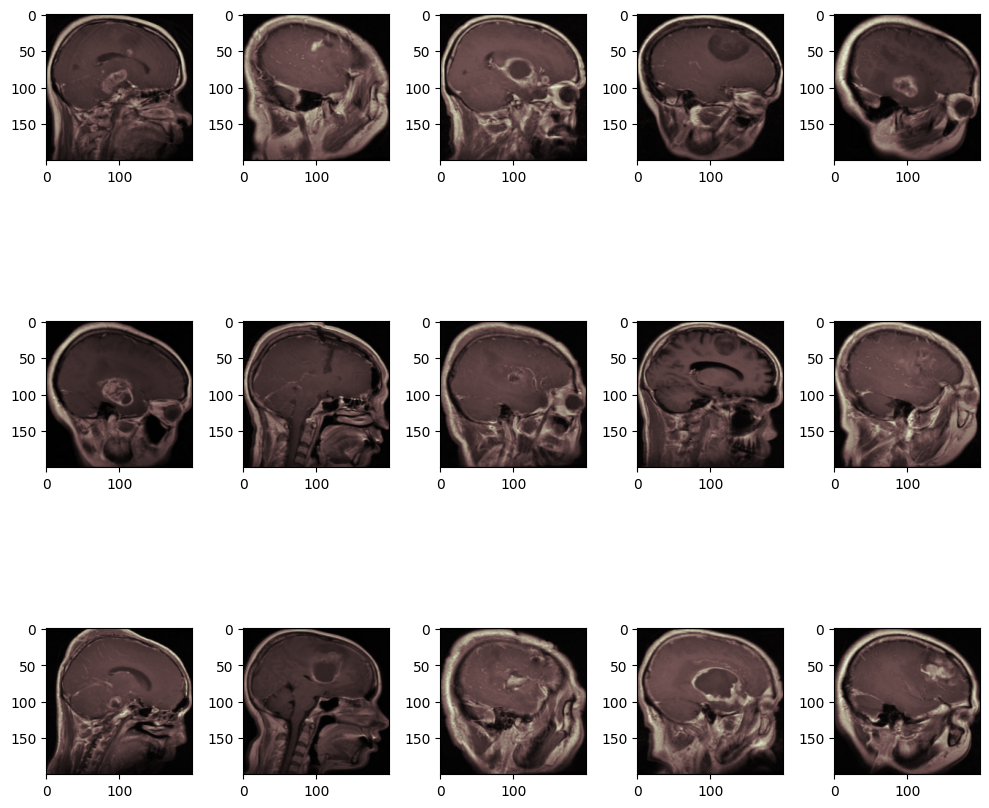

In [ ]:
images = [x_train[i] for i in range(15)]
fig, axes = plt.subplots(3, 5, figsize = (10, 10))
axes = axes.flatten()
for img, ax in zip(images, axes):
    ax.imshow(img)
plt.tight_layout()
plt.show()

In [ ]:
x_train, y_train = shuffle(x_train,y_train, random_state=42)

y_train = tensorflow.keras.utils.to_categorical(y_train)
y_test = tensorflow.keras.utils.to_categorical(y_test)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)
print(x_val.shape)
print(y_test.shape)

(1144, 200, 200, 3)
(1311, 4)


In [ ]:
def make_gradcam_heatmap(img_array, grad_model, class_idx):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]  # (H, W, channels)
    heatmap = tf.zeros(shape=conv_outputs.shape[:2], dtype=tf.float32)
    for i in range(pooled_grads.shape[-1]):
        heatmap += pooled_grads[i] * conv_outputs[:, :, i]

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

Model Resnet50 - Average Drop: 40.11%
Model InceptionV3 - Average Drop: 70.52%
Model Densenet121 - Average Drop: 62.07%
Model VGG16 - Average Drop: 48.29%
Model EfficientnetB3 - Average Drop: 46.71%


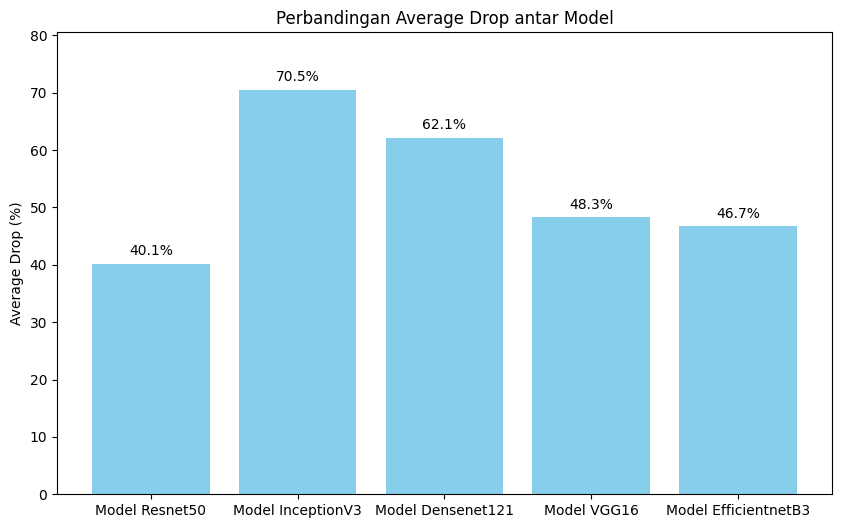

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
model_paths = ['/content/drive/MyDrive/modelres50.h5',
               '/content/drive/MyDrive/modelinceptionv3.h5',
               '/content/drive/MyDrive/modelDensenet121.h5',
               '/content/drive/MyDrive/modelVGG16.h5',
               '/content/drive/MyDrive/modelEfficientNetB3.h5'
               ]
model_list = [load_model(path) for path in model_paths]
model_names = ['Model Resnet50', 'Model InceptionV3', 'Model Densenet121', 'Model VGG16', 'Model EfficientnetB3']
layer_names = ['conv5_block3_out', 'mixed10', 'conv5_block16_2_conv', 'block5_conv3', 'top_conv']  # layer conv terakhir tiap model

avg_drop_scores = []

for idx, (model, layer_name) in enumerate(zip(model_list, layer_names)):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    drop_list = []
    for i in range(len(x_test)):
        img = x_test[i]
        label = y_test[i]
        img_input = np.expand_dims(img, axis=0)

        preds = model.predict(img_input, verbose=0)
        pred_idx = np.argmax(preds[0])
        original_conf = preds[0][pred_idx]

        # Grad-CAM
        heatmap = make_gradcam_heatmap(img_input, grad_model, pred_idx)

        # Masking
        threshold = 0.3
        mask = np.where(heatmap >= threshold, 0, 1).astype(np.float32)
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

        img_masked = img * mask[..., np.newaxis]
        img_masked_input = np.expand_dims(img_masked, axis=0)

        preds_masked = model.predict(img_masked_input, verbose=0)
        masked_conf = preds_masked[0][pred_idx]

        drop = max(0, original_conf - masked_conf)
        drop_percent = drop / original_conf * 100
        drop_list.append(drop_percent)

    avg_drop = np.mean(drop_list)
    avg_drop_scores.append(avg_drop)
    print(f"{model_names[idx]} - Average Drop: {avg_drop:.2f}%")

# 📊 Visualisasi
plt.figure(figsize=(10,6))
plt.bar(model_names, avg_drop_scores, color='skyblue')
plt.ylabel("Average Drop (%)")
plt.title("Perbandingan Average Drop antar Model")
plt.ylim(0, max(avg_drop_scores) + 10)
for i, val in enumerate(avg_drop_scores):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', va='bottom')
plt.show()
